# Airbnb Athens - Price Prediction

This project analyzes Airbnb listings in Athens and builds machine learning models to predict listing prices based on location,property features, and availability.


## 1. Data loading
The dataset is loaded from a compressed CSV file containing Airbnb listings in Athens.Only the relevant columns are selected to focus on price prediction and improve efficiency.

In [63]:
import pandas as pd
import os

file_path="data/listings.csv.gz"
if os.path.exists(file_path):
  df=pd.read_csv(file_path)
else:
  from google.colab import files
  print("Upload dataset")
  files.upload()
  df=pd.read_csv("listings.csv.gz")

df.head()

Upload dataset


Saving listings.csv.gz to listings.csv.gz


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,27262,https://www.airbnb.com/rooms/27262,20250926033717,2025-09-27,previous scrape,"AQA-No7, Great mattress, high speed internet",THE MATTRESS - KING KOIL - Camden Luxury 160x2...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,37177,...,4.97,4.75,4.71,00002433111,t,1,1,0,0,0.18
1,33945,https://www.airbnb.com/rooms/33945,20250926033717,2025-09-26,city scrape,Spacious Cosy aprtm very close to Metro!,Apartment located near metro station. Safe nei...,Neighbourhood is alive all day and safe all da...,https://a0.muscache.com/pictures/1a7a1026-f5f1...,146553,...,4.91,4.64,4.81,00000874421,f,1,1,0,0,0.49
2,49489,https://www.airbnb.com/rooms/49489,20250926033717,2025-09-26,city scrape,Ermou 44 - 3bdr apt in the heart of Athens,"Fully furnished, 98 sq.mt., apartment on 44 Er...",The apartment is located at the commercial cen...,https://a0.muscache.com/pictures/9640239/4bfd2...,225612,...,4.87,4.89,4.69,00000876484,t,3,3,0,0,0.83
3,60394,https://www.airbnb.com/rooms/60394,20250926033717,2025-09-26,city scrape,Cosy apartment! Great central Athens location!,Fully furnished cozy apartment in the best nei...,Very centrally located with a feeling of a qui...,https://a0.muscache.com/pictures/477282/db550f...,290864,...,4.97,4.92,4.92,00000508830,f,1,1,0,0,0.29
4,134340,https://www.airbnb.com/rooms/134340,20250926033717,2025-09-27,previous scrape,Neo Pagrati Athens Apartment,Little gem with the best of all worlds! Locate...,Our street is a small one with very little tra...,https://a0.muscache.com/pictures/1232312/4edeb...,659406,...,4.93,4.56,4.83,00002821300,f,1,1,0,0,0.36


In [65]:
df.shape

(15584, 79)

In [66]:
df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15584 entries, 0 to 15583
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            15584 non-null  int64  
 1   listing_url                                   15584 non-null  object 
 2   scrape_id                                     15584 non-null  int64  
 3   last_scraped                                  15584 non-null  object 
 4   source                                        15584 non-null  object 
 5   name                                          15584 non-null  object 
 6   description                                   15247 non-null  object 
 7   neighborhood_overview                         7509 non-null   object 
 8   picture_url                                   15584 non-null  object 
 9   host_id                                       15584 non-null 

In [68]:
cols=[
    "price",
    "neighbourhood_cleansed",
    "room_type",
    "latitude",
    "longitude",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "number_of_reviews",
    "availability_365",
    "review_scores_rating"
]
df=df[cols]
df.shape

(15584, 13)

In [69]:
df.head()

,price,neighbourhood_cleansed,room_type,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,number_of_reviews,availability_365,review_scores_rating
0,NaN,ΑΜΠΕΛΟΚΗΠΟΙ,Entire home/apt,37.98924,23.76500,2,NaN,1.0,NaN,1,29,0,4.86
1,$45.00,ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ,Entire home/apt,38.00673,23.72775,4,1.0,2.0,3.0,4,89,269,4.76
2,$160.00,ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,Entire home/apt,37.97670,23.73064,7,1.5,3.0,4.0,2,142,72,4.68
3,$50.00,ΣΤΑΔΙΟ,Entire home/apt,37.96738,23.74038,2,1.0,1.0,3.0,6,37,54,4.97
4,NaN,ΠΑΓΚΡΑΤΙ,Entire home/apt,37.96405,23.74968,2,NaN,1.0,NaN,3,61,0,4.68


## 2. Data cleaning
The raw data needs a few cleaning steps before analysis:

- The `price` column is stored as a string (e.g. `$120.00`), so I removed the `$` symbol and converted it to a number.
- Rows with missing prices were removed, since price is the value I want to predict.
- Missing values in `beds`, `bedrooms`, `bathrooms`, and `review_scores_rating` were filled using the median.
- Very large price values (top 1%) were removed to avoid extreme outliers affecting the model.

In [70]:
df=df.dropna(subset=["price"])
df["price"]=df["price"].replace(r'[\$,]', '',regex=True).astype(float)
df["price"].head()

,price
1,45.0
2,160.0
3,50.0
5,70.0
6,57.0


In [71]:
df=df.reset_index(drop=True)
df.head()

,price,neighbourhood_cleansed,room_type,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,number_of_reviews,availability_365,review_scores_rating
0,45.0,ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ,Entire home/apt,38.00673,23.72775,4,1.0,2.0,3.0,4,89,269,4.76
1,160.0,ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,Entire home/apt,37.97670,23.73064,7,1.5,3.0,4.0,2,142,72,4.68
2,50.0,ΣΤΑΔΙΟ,Entire home/apt,37.96738,23.74038,2,1.0,1.0,3.0,6,37,54,4.97
3,70.0,ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ,Entire home/apt,37.98574,23.73323,4,1.0,1.0,2.0,2,225,347,4.73
4,57.0,ΑΚΡΟΠΟΛΗ,Entire home/apt,37.96828,23.72906,3,1.0,1.0,1.0,2,65,0,4.77


In [72]:
df.isnull().sum().sort_values(ascending=False)

,0
review_scores_rating,2112
beds,27
bedrooms,14
bathrooms,3
price,0
longitude,0
latitude,0
room_type,0
neighbourhood_cleansed,0
accommodates,0


In [73]:
df["beds"]=df["beds"].fillna(df["beds"].median())
df["bedrooms"]=df["bedrooms"].fillna(df["bedrooms"].median())
df["bathrooms"]=df["bathrooms"].fillna(df["bathrooms"].median())
df["review_scores_rating"]=df["review_scores_rating"].fillna(df["review_scores_rating"].median())

In [74]:
df.isnull().sum()

,0
price,0
neighbourhood_cleansed,0
room_type,0
latitude,0
longitude,0
accommodates,0
bathrooms,0
bedrooms,0
beds,0
minimum_nights,0


## 3. Exploratory Data Analysis


Before building the models, I explored the data to better understand patterns and relationships:

- **Price distribution:** The distribution is right-skewed, with most listings priced between €30–€150 per night.
- **Price by room type:** Entire homes tend to be more expensive than private or shared rooms.
- **Price by neighbourhood:** Some areas (e.g. Acropolis, Kolonaki) have higher median prices.
- **Geographic spread:** The scatter plot shows that listings are concentrated in central Athens, with higher prices in those areas.

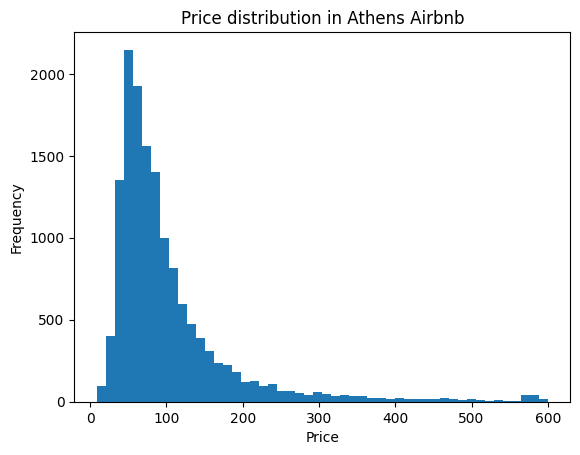

In [75]:
import matplotlib.pyplot as plt
df=df[df["price"]<df["price"].quantile(0.99)]
plt.hist(df["price"],bins=50)
plt.title("Price distribution in Athens Airbnb")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

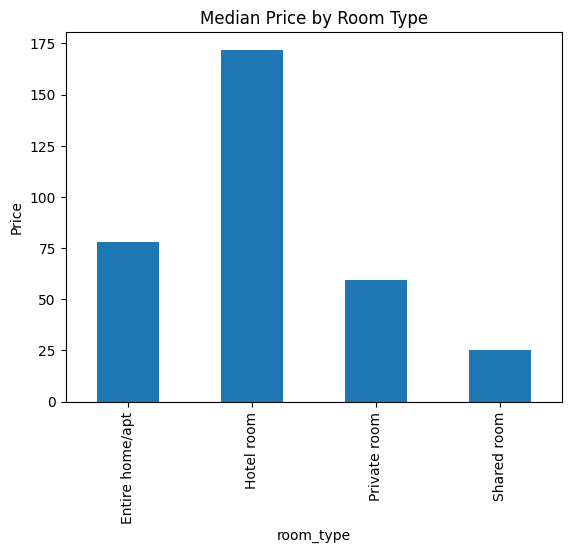

In [76]:
df.groupby("room_type")["price"].median().plot(kind="bar")
plt.title("Median Price by Room Type")
plt.ylabel("Price")
plt.show()

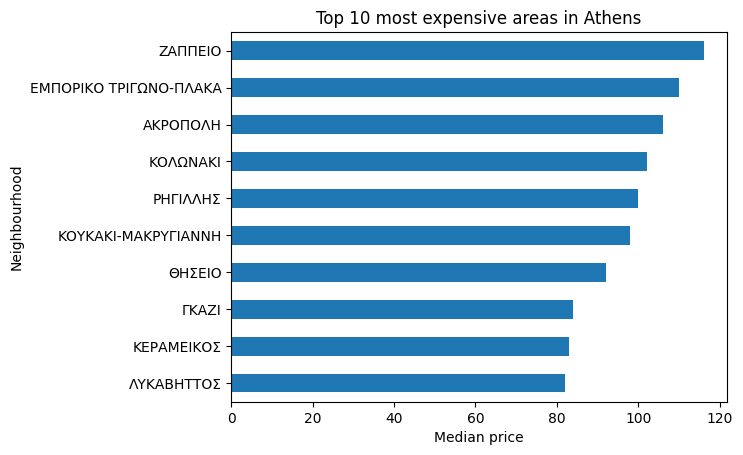

In [85]:
df.groupby("neighbourhood_cleansed")["price"].median()\
  .sort_values(ascending=False).head(10)\
  .sort_values(ascending=True)\
  .plot(kind="barh")
plt.title("Top 10 most expensive areas in Athens")
plt.xlabel("Median price")
plt.ylabel("Neighbourhood")
plt.show()

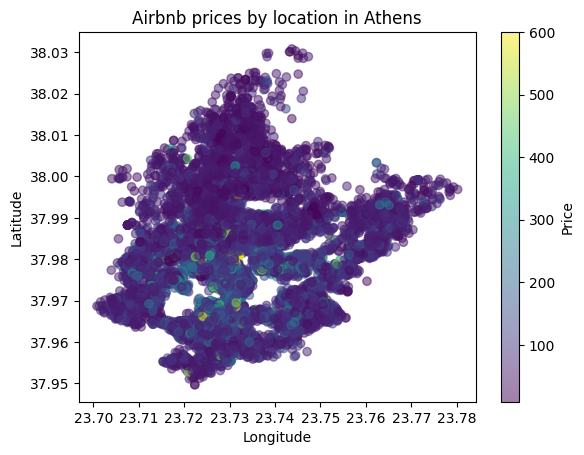

In [78]:
plt.scatter(df["longitude"],df["latitude"],c=df["price"],alpha=0.5)
plt.colorbar(label="Price")
plt.title("Airbnb prices by location in Athens")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## 4. Feature Engineering

To prepare the data for modeling, I converted categorical variables (`room_type` and `neighbourhood_cleansed`) into numeric format using one-hot encoding (`pd.get_dummies()`).

I used `drop_first=True` to avoid creating redundant columns.

The rest of the features are already numeric, so they were used without further changes.

In [39]:
X=df.drop("price",axis=1)
y=df["price"]

In [ ]:
X=pd.get_dummies(X,columns=["room_type","neighbourhood_cleansed"],drop_first=True)

## 5. Modeling

To predict Airbnb prices, I trained two regression models using an 80/20 train-test split:

1. **Linear Regression** — used as a simple baseline model that assumes a linear relationship between features and price.
2. **Random Forest Regressor** — a more complex model based on multiple decision trees, which can capture non-linear patterns.

Both models are evaluated using **MAE** (Mean Absolute Error) and **R²**, to measure prediction accuracy and overall performance.

In [45]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X.head()

,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,number_of_reviews,availability_365,review_scores_rating,...,neighbourhood_cleansed_ΠΕΤΡΑΛΩΝΑ,neighbourhood_cleansed_ΠΛΑΤΕΙΑ ΑΜΕΡΙΚΗΣ,neighbourhood_cleansed_ΠΛΑΤΕΙΑ ΑΤΤΙΚΗΣ,neighbourhood_cleansed_ΠΟΛΥΓΩΝΟ,neighbourhood_cleansed_ΠΡΟΜΠΟΝΑ,neighbourhood_cleansed_ΡΗΓΙΛΛΗΣ,neighbourhood_cleansed_ΡΙΖΟΥΠΟΛΗ,neighbourhood_cleansed_ΣΕΠΟΛΙΑ,neighbourhood_cleansed_ΣΤΑΔΙΟ,neighbourhood_cleansed_ΣΤΑΘΜΟΣ ΛΑΡΙΣΗΣ
0,38.00673,23.72775,4,1.0,2.0,3.0,4,89,269,4.76,...,False,False,False,False,False,False,False,False,False,False
1,37.97670,23.73064,7,1.5,3.0,4.0,2,142,72,4.68,...,False,False,False,False,False,False,False,False,False,False
2,37.96738,23.74038,2,1.0,1.0,3.0,6,37,54,4.97,...,False,False,False,False,False,False,False,False,True,False
3,37.98574,23.73323,4,1.0,1.0,2.0,2,225,347,4.73,...,False,False,False,False,False,False,False,False,False,False
4,37.96828,23.72906,3,1.0,1.0,1.0,2,65,0,4.77,...,False,False,False,False,False,False,False,False,False,False


In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score

model=LinearRegression()
model.fit(X_train,y_train)

y_pred=model.predict(X_test)
print("MAE:",mean_absolute_error(y_test,y_pred))
print("R2:",r2_score(y_test,y_pred))


MAE: 40.696262491550605
R2: 0.36266069331395856


In [49]:
from sklearn.ensemble import RandomForestRegressor


rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

y_pred_rf=rf.predict(X_test)
print("MAE:",mean_absolute_error(y_test,y_pred_rf))
print("R2:",r2_score(y_test,y_pred_rf))


MAE: 30.495643245903956
R2: 0.6200011514978496


## 6. Feature Importance

Random Forest provides feature importance scores that show how much each variable contributes to the predictions.

I used this to identify the most important factors influencing Airbnb prices and displayed the top 10 features.

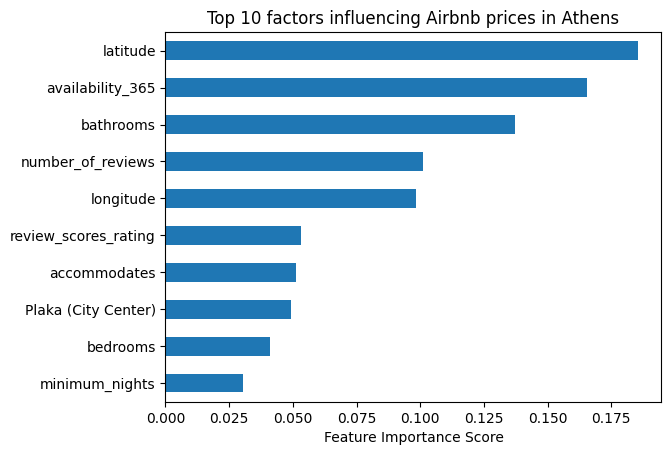

In [82]:
importances=rf.feature_importances_
features=X.columns

feat_imp=pd.Series(importances,index=features).sort_values(ascending=False)

feat_imp_clean=feat_imp.copy()
feat_imp_clean.index=feat_imp_clean.index.str.replace("neighbourhood_cleansed_","",regex=False)
feat_imp_clean.index=feat_imp_clean.index.str.replace("room_type_","",regex=False)

mapping = {
    "ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ": "Plaka (City Center)",
    "ΑΚΡΟΠΟΛΗ": "Acropolis",
    "ΚΟΛΩΝΑΚΙ": "Kolonaki"
}

feat_imp_clean.index=feat_imp_clean.index.map(lambda x:mapping.get(x,x))
feat_imp_clean.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 factors influencing Airbnb prices in Athens")
plt.xlabel("Feature Importance Score")
plt.show()

## 7. Conclusions

| Model             | MAE  | R²   |
|-------------------|------|------|
| Linear Regression | 40.7 | 0.36 |
| Random Forest     | 30.5 | 0.62 |

**Key findings:**
- Location (neighbourhood) is the strongest predictor of price.
- Room type has a significant impact — entire homes are more expensive than private or shared rooms.
- Property characteristics such as size (accommodates, bedrooms) and availability also influence pricing.

**Limitations & next steps:**
- Additional features (e.g. amenities, host information) could improve the model.
- Hyperparameter tuning could further improve Random Forest performance.